In [ ]:
pip install torch

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings, gc
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")

Device : cuda


In [3]:
sales = pd.read_feather('/kaggle/input/datasets/nevilmathewshelly/updated-sq/sales_features.feather')
sales['date'] = pd.to_datetime(sales['date'])

mask = (
    (sales['store_id'] == 'CA_1') &
    (sales['dept_id']  == 'FOODS_1')
)
subset = sales[mask].copy()

top_items = (
    subset.groupby('item_id')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index.tolist()
)

multi = subset[subset['item_id'].isin(top_items)].copy()
multi = multi.sort_values(['item_id','date']).reset_index(drop=True)

print(f"Items : {multi['item_id'].nunique()}")
print(f"Rows  : {len(multi):,}")

Items : 50
Rows  : 97,050


In [4]:
le = LabelEncoder()
multi['item_enc'] = le.fit_transform(multi['item_id'])

feature_cols  = ['sales','sell_price','snap_CA','has_event',
                 'event_type_enc','day_of_week','month','is_weekend','item_enc']
cols_to_scale = ['sales','sell_price','snap_CA','has_event',
                 'event_type_enc','day_of_week','month','is_weekend']

cutoff   = multi['date'].max() - pd.Timedelta(days=28)
train_df = multi[multi['date'] <= cutoff]
test_df  = multi[multi['date'] >  cutoff]

# Fit scalers on train only
scaler_X = StandardScaler()
scaler_y = StandardScaler()

train_X = train_df[feature_cols].copy()
test_X  = test_df[feature_cols].copy()

train_X[cols_to_scale] = scaler_X.fit_transform(train_df[cols_to_scale])
test_X[cols_to_scale]  = scaler_X.transform(test_df[cols_to_scale])

train_y = scaler_y.fit_transform(train_df[['sales']])
test_y  = scaler_y.transform(test_df[['sales']])

print(f"Train : {train_X.shape} | Test : {test_X.shape}")

Train : (95650, 9) | Test : (1400, 9)


In [5]:
INPUT_LEN  = 28
OUTPUT_LEN = 28

def create_sequences_per_item(df_X, df_y, item_col='item_enc',
                               input_len=28, output_len=28):
    X_all, y_all = [], []
    for item_id in df_X[item_col].unique():
        mask   = df_X[item_col] == item_id
        item_X = df_X[mask].values.astype(np.float32)
        item_y = df_y[mask.values].astype(np.float32)
        for i in range(len(item_X) - input_len - output_len + 1):
            X_all.append(item_X[i : i + input_len])
            y_all.append(item_y[i + input_len : i + input_len + output_len])
    return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32)

def create_test_sequences(train_X, train_y, test_X, test_y,
                           item_col='item_enc', input_len=28, output_len=28):
    X_all, y_all = [], []
    for item_id in train_X[item_col].unique():
        train_mask = train_X[item_col] == item_id
        test_mask  = test_X[item_col]  == item_id
        item_train_X = train_X[train_mask].values.astype(np.float32)
        item_test_y  = test_y[test_mask.values].astype(np.float32)
        if len(item_train_X) >= input_len and len(item_test_y) >= output_len:
            X_all.append(item_train_X[-input_len:])
            y_all.append(item_test_y[:output_len])
    return np.array(X_all, dtype=np.float32), np.array(y_all, dtype=np.float32)

X_train_seq, y_train_seq = create_sequences_per_item(
    train_X, train_y, input_len=INPUT_LEN, output_len=OUTPUT_LEN)
X_test_seq, y_test_seq   = create_test_sequences(
    train_X, train_y, test_X, test_y,
    input_len=INPUT_LEN, output_len=OUTPUT_LEN)

print(f"X_train : {X_train_seq.shape}")
print(f"X_test  : {X_test_seq.shape}")

X_train : (92900, 28, 9)
X_test  : (50, 28, 9)


In [6]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

val_size  = int(len(X_train_seq) * 0.1)
X_val     = X_train_seq[-val_size:]
y_val     = y_train_seq[-val_size:]
X_train_f = X_train_seq[:-val_size]
y_train_f = y_train_seq[:-val_size]
X_test    = torch.tensor(X_test_seq)
y_test    = torch.tensor(y_test_seq)

train_loader = DataLoader(SeqDataset(X_train_f, y_train_f), batch_size=64, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, y_val),         batch_size=64, shuffle=False)

print(f"Train : {len(X_train_f):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")

Train : 83,610 | Val : 9,290 | Test : 50


In [7]:
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size * 2, hidden_size)
        self.v    = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        batch, seq_len, _ = encoder_outputs.shape
        hidden = hidden.permute(1, 0, 2).repeat(1, seq_len, 1)
        energy = torch.tanh(self.attn(torch.cat([hidden, encoder_outputs], dim=2)))
        attn_weights = torch.softmax(self.v(energy).squeeze(2), dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        return context, attn_weights

class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.3):
        super().__init__()
        self.gru     = nn.GRU(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        outputs, hidden = self.gru(self.dropout(x))
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size=1, dropout=0.3):
        super().__init__()
        self.gru       = nn.GRU(1 + hidden_size, hidden_size, batch_first=True)
        self.attention = Attention(hidden_size)
        self.fc        = nn.Linear(hidden_size * 2, output_size)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, hidden, encoder_outputs):
        x       = x.unsqueeze(1).unsqueeze(2)
        context, attn_weights = self.attention(hidden, encoder_outputs)
        gru_input = torch.cat([x, context], dim=2)
        output, hidden = self.gru(self.dropout(gru_input), hidden)
        pred = self.fc(torch.cat([output, context], dim=2))
        return pred.squeeze(2), hidden, attn_weights

class Seq2Seq(nn.Module):
    def __init__(self, input_size, hidden_size, output_len, dropout=0.3):
        super().__init__()
        self.encoder    = Encoder(input_size, hidden_size, dropout)
        self.decoder    = Decoder(hidden_size, 1, dropout)
        self.output_len = output_len

    def forward(self, x, targets=None, teacher_forcing_ratio=0.5):
        encoder_outputs, hidden = self.encoder(x)
        decoder_input = x[:, -1, 0]
        predictions   = []
        for t in range(self.output_len):
            pred, hidden, _ = self.decoder(decoder_input, hidden, encoder_outputs)
            predictions.append(pred)
            if targets is not None and torch.rand(1).item() < teacher_forcing_ratio:
                decoder_input = targets[:, t, 0]
            else:
                decoder_input = pred.squeeze(1)
        return torch.stack(predictions, dim=1)

HIDDEN_SIZE = 64
INPUT_SIZE  = X_train_seq.shape[2]

model_seq2seq = Seq2Seq(
    input_size  = INPUT_SIZE,
    hidden_size = HIDDEN_SIZE,
    output_len  = OUTPUT_LEN,
    dropout     = 0.3
).to(device)

print(f"Parameters : {sum(p.numel() for p in model_seq2seq.parameters()):,}")

Parameters : 48,001


Epoch  10 | Train: 0.456876 | Val: 0.859961 | Patience: 4/20 | TF: 0.476 | LR: 0.001000
Epoch  20 | Train: 0.427919 | Val: 0.891988 | Patience: 14/20 | TF: 0.452 | LR: 0.000250
Early stopping at epoch 26

Best val loss : 0.784596 ✅


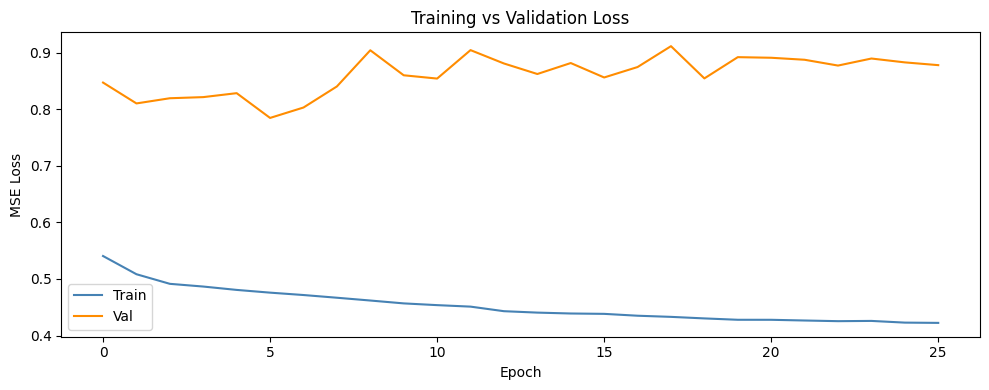

In [8]:
optimizer  = optim.Adam(model_seq2seq.parameters(), lr=0.001)
criterion  = nn.MSELoss()
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS           = 100
patience         = 20        # ← increased from 15
best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []
tf_ratio = 0.5

for epoch in range(EPOCHS):
    model_seq2seq.train()
    epoch_loss = 0
    tf_ratio = max(0.1, tf_ratio * 0.995)   # ← slower decay (was 0.98)

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        predictions = model_seq2seq(X_batch, targets=y_batch,
                                    teacher_forcing_ratio=tf_ratio)
        loss = criterion(predictions, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_seq2seq.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    model_seq2seq.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            pred = model_seq2seq(X_batch.to(device),
                                 targets=None, teacher_forcing_ratio=0.0)
            val_loss += criterion(pred, y_batch.to(device)).item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model_seq2seq.state_dict(), 'seq2seq_best.pt')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:3d} | Train: {avg_train:.6f} | Val: {avg_val:.6f} | "
              f"Patience: {patience_counter}/{patience} | TF: {tf_ratio:.3f} | LR: {lr:.6f}")

print(f"\nBest val loss : {best_val_loss:.6f} ✅")

# Training curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train', color='steelblue')
plt.plot(val_losses,   label='Val',   color='darkorange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
def mc_dropout_predict(model, X, n_samples=100):
    model.train()
    preds = []
    with torch.no_grad():
        for _ in range(n_samples):
            pred = model(X.to(device), teacher_forcing_ratio=0.0)
            preds.append(pred.cpu().numpy())
    preds = np.array(preds)
    return preds.mean(axis=0), preds.std(axis=0)

model_seq2seq.load_state_dict(torch.load('seq2seq_best.pt'))

mean_pred, std_pred = mc_dropout_predict(model_seq2seq, X_test)

# Inverse transform
mean_pred_inv = scaler_y.inverse_transform(
    mean_pred.squeeze(-1).reshape(-1,1)).reshape(mean_pred.squeeze(-1).shape)
std_pred_inv  = std_pred.squeeze(-1) * scaler_y.scale_[0]
y_test_inv    = scaler_y.inverse_transform(
    y_test.numpy().squeeze(-1).reshape(-1,1)).reshape(y_test.numpy().squeeze(-1).shape)

mean_pred_inv = np.clip(mean_pred_inv, 0, None)

# Metrics
y_true_flat = y_test_inv.flatten()
y_pred_flat = mean_pred_inv.flatten()

mae_s  = mean_absolute_error(y_true_flat, y_pred_flat)
rmse_s = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))

# Corrected MASE — per item
naive_maes = [
    mean_absolute_error(y_test_inv[i, 1:], y_test_inv[i, :-1])
    for i in range(y_test_inv.shape[0])
    if y_test_inv[i].std() > 0   # skip flat series
]
mase_s = mae_s / np.mean(naive_maes)

print("=" * 40)
print("Seq2Seq — 28-day forecast evaluation")
print("=" * 40)
print(f"MAE   : {mae_s:.4f}")
print(f"RMSE  : {rmse_s:.4f}")
print(f"MASE  : {mase_s:.4f}")
print("=" * 40)

Seq2Seq — 28-day forecast evaluation
MAE   : 2.4800
RMSE  : 3.5700
MASE  : 0.9120
